In [1]:
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("../data/dataset.csv")

In [3]:
features = [
    "Age at enrollment",
    "Gender",
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]

X = df[features]

y = df["Target"]

In [4]:
X = pd.get_dummies(
    X,
    columns=[
        "Gender",
        "Debtor",
        "Tuition fees up to date"
    ],
    drop_first=True
)

In [5]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [7]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

In [8]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average='weighted'
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average='weighted'
)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Precision:", rf_precision)
print("Random Forest Recall:", rf_recall)

Random Forest Accuracy: 0.6807228915662651
Random Forest Precision: 0.6495406357253748
Random Forest Recall: 0.6807228915662651


In [9]:
rf_cm = confusion_matrix(y_test, rf_predictions)

print(rf_cm)

[[300  47  94]
 [ 68  45 132]
 [ 43  40 559]]


In [10]:
rf_cv_scores = cross_val_score(
    random_forest,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:", rf_cv_scores)
print("Mean CV Score:", rf_cv_scores.mean())

Cross Validation Scores: [0.67344633 0.67683616 0.66892655 0.69830508 0.68438914]
Mean CV Score: 0.6803806529130558


In [11]:
gradient_boost = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gradient_boost.fit(X_train, y_train)

gb_predictions = gradient_boost.predict(X_test)

In [12]:
gb_accuracy = accuracy_score(y_test, gb_predictions)

gb_precision = precision_score(
    y_test,
    gb_predictions,
    average='weighted'
)

gb_recall = recall_score(
    y_test,
    gb_predictions,
    average='weighted'
)

print("Gradient Boosting Accuracy:", gb_accuracy)
print("Gradient Boosting Precision:", gb_precision)
print("Gradient Boosting Recall:", gb_recall)

Gradient Boosting Accuracy: 0.7070783132530121
Gradient Boosting Precision: 0.6761677663033085
Gradient Boosting Recall: 0.7070783132530121


In [13]:
gb_cm = confusion_matrix(y_test, gb_predictions)

print(gb_cm)

[[304  46  91]
 [ 64  44 137]
 [ 37  14 591]]


In [14]:
gb_cv_scores = cross_val_score(
    gradient_boost,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:", gb_cv_scores)
print("Mean CV Score:", gb_cv_scores.mean())

Cross Validation Scores: [0.71186441 0.70621469 0.7039548  0.71638418 0.70248869]
Mean CV Score: 0.7081813533757702


In [15]:
print("===== MODEL COMPARISON =====")

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")

print(f"Random Forest Mean CV Score: {rf_cv_scores.mean():.4f}")
print(f"Gradient Boosting Mean CV Score: {gb_cv_scores.mean():.4f}")

===== MODEL COMPARISON =====
Random Forest Accuracy: 0.6807
Gradient Boosting Accuracy: 0.7071
Random Forest Mean CV Score: 0.6804
Gradient Boosting Mean CV Score: 0.7082


In [16]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
1,Curricular units 1st sem (approved),0.528887
0,Age at enrollment,0.283859
4,Tuition fees up to date_1,0.120574
3,Debtor_1,0.033748
2,Gender_1,0.032932


<Axes: xlabel='Feature'>

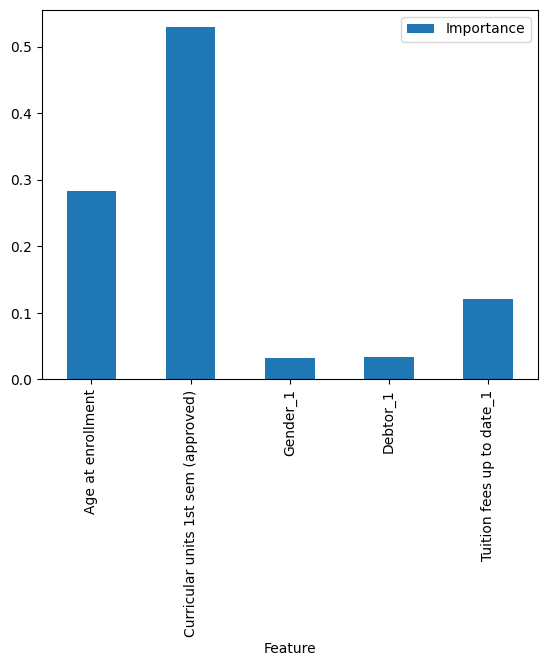

In [17]:
feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)